# Task 1 — Web Scraping of Job Listings from JustJoin.it

**Objective:** Scrape job titles, companies, locations, salaries, and categories
from JustJoin.it for all Polish cities using requests and BeautifulSoup.

**Pipeline:**
1. Send HTTP requests directly to JustJoin.it
2. Parse HTML with BeautifulSoup to extract job fields
3. Store results in a Pandas DataFrame
4. Clean, analyze, and visualize findings

## 1. Import Libraries

In [3]:
# requests sends HTTP GET requests to JustJoin.it
import requests

# BeautifulSoup parses the raw HTML and lets us navigate the DOM tree
from bs4 import BeautifulSoup

# Pandas for storing, cleaning, and analyzing scraped data
import pandas as pd
import numpy as np

# re for regex-based salary parsing
import re

# time for polite delays between requests
import time

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')


All libraries imported successfully.


## 2. Configure Settings

In [6]:
# ── Browser headers ───────────────────────────────────────────────────────────
# We mimic a real Chrome browser so JustJoin.it serves us the full HTML page.
# Without these headers the site may block or return an empty response.
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8',
    'Accept-Language': 'en-US,en;q=0.9',
    'Accept-Encoding': 'gzip, deflate, br',
    'Connection': 'keep-alive',
    'Upgrade-Insecure-Requests': '1',
    'Cache-Control': 'max-age=0',
}

# ── Target URL ────────────────────────────────────────────────────────────────
# This URL returns all job listings across all Polish cities and all categories
BASE_URL = 'https://justjoin.it/'

# ── Pagination config ─────────────────────────────────────────────────────────
# JustJoin.it paginates via ?page=N parameter
# Each page contains ~20-30 job cards
# Set MAX_PAGES to None to scrape all available pages
MAX_PAGES = 200   # ~200-300 jobs. Set to None for all pages.
REQUEST_DELAY = 2  # Seconds between page requests (polite scraping)

print(f'Target: {BASE_URL}')
print(f'Max pages: {MAX_PAGES} (~{MAX_PAGES * 25 if MAX_PAGES else "all"} jobs)')
print(f'Delay between requests: {REQUEST_DELAY}s')


Target: https://justjoin.it/
Max pages: 200 (~5000 jobs)
Delay between requests: 2s


## 3. Define Scraping Functions

In [9]:
def fetch_page(url: str) -> BeautifulSoup | None:
    """
    Sends a GET request to the given URL and returns a BeautifulSoup object.
    Returns None if the request fails or returns a non-200 status.
    """
    try:
        r = requests.get(url, headers=HEADERS, timeout=15)
        if r.status_code != 200:
            print(f'  [!] HTTP {r.status_code} for {url}')
            return None
        return BeautifulSoup(r.text, 'html.parser')
    except Exception as e:
        print(f'  [!] Request error: {e}')
        return None


def parse_jobs(soup: BeautifulSoup) -> list:
    """
    Extracts all job listings from a parsed JustJoin.it page.

    HTML structure (from DevTools inspection):
      Job card:  <a class='offer-card' href='/job-offer/...'>
      Title:     <h3> inside the card
      Salary:    <span class='...xgxsaw'>
      Company:   first <p class='...15bqx6t'>
      City:      <span class='...1o4wo1x'>
      Remote:    <p class='...15bqx6t'> containing 'Remote'
      skills:      <div class='...jikuwi'> elements
    """
    jobs = []
    cards = soup.find_all('a', class_='offer-card')

    for card in cards:
        # ── URL & Job ID ──────────────────────────────────────────────────────
        href = card.get('href', '')
        job_id = href.split('/')[-1] if href else 'N/A'

        # ── Title ─────────────────────────────────────────────────────────────
        title_tag = card.find('h3')
        title = title_tag.get_text(strip=True) if title_tag else 'N/A'

        # ── Salary ────────────────────────────────────────────────────────────
        salary_tag = card.find('span', class_=lambda c: c and 'xgxsaw' in c)
        salary = salary_tag.get_text(strip=True) if salary_tag else 'Not listed'

        # ── Company & Remote ──────────────────────────────────────────────────
        p_skills = card.find_all('p', class_=lambda c: c and '15bqx6t' in c)
        company = p_skills[0].get_text(strip=True) if p_skills else 'N/A'
        remote = any('Remote' in p.get_text() for p in p_skills)

        # ── City ──────────────────────────────────────────────────────────────
        city_tag = card.find('span', class_=lambda c: c and '1o4wo1x' in c)
        city = city_tag.get_text(strip=True) if city_tag else 'N/A'

        # ── skills (category labels on card) ────────────────────────────────────
        tag_divs = card.find_all('div', class_=lambda c: c and 'jikuwi' in c)
        all_skills = [d.get_text(strip=True) for d in tag_divs]

        # Separate 'Xd left' badge from actual category skills
        days_left_tag = card.find('div', class_=lambda c: c and '4itb31' in c)
        days_left = days_left_tag.get_text(strip=True) if days_left_tag else 'N/A'
        category_skills = [t for t in all_skills if t != days_left]

        jobs.append({
            'job_id':    job_id,
            'title':     title,
            'company':   company,
            'city':      city,
            'remote':    remote,
            'salary':    salary,
            'skills':      ', '.join(category_skills),
            'days_left': days_left,
            'url':       'https://justjoin.it' + href,
        })

    return jobs


print('Functions defined: fetch_page(), parse_jobs()')


Functions defined: fetch_page(), parse_jobs()


## 4. Run the Scraper

In [11]:
# ── Main scraping loop ────────────────────────────────────────────────────────
# We iterate through pages using ?page=N parameter.
# We stop when either MAX_PAGES is reached or a page returns 0 job cards
# (meaning we've gone past the last page).

all_jobs = []
page = 1

while True:
    if MAX_PAGES is not None and page > MAX_PAGES:
        print(f'Reached MAX_PAGES ({MAX_PAGES}). Stopping.')
        break

    url = f'{BASE_URL}?page={page}'
    print(f'Scraping page {page}: {url}')

    soup = fetch_page(url)
    if soup is None:
        print(f'  Failed to fetch page {page}. Stopping.')
        break

    page_jobs = parse_jobs(soup)
    print(f'  Found {len(page_jobs)} jobs on page {page}')

    # If no jobs found on this page — we've gone past the last page
    if len(page_jobs) == 0:
        print('  No jobs found — reached end of listings.')
        break

    all_jobs.extend(page_jobs)
    page += 1

    # Polite delay between requests
    if MAX_PAGES is None or page <= MAX_PAGES:
        time.sleep(REQUEST_DELAY)

print(f'\nScraping complete. Total jobs collected: {len(all_jobs)}')


Scraping page 1: https://justjoin.it/?page=1
  Found 100 jobs on page 1
Scraping page 2: https://justjoin.it/?page=2
  Found 100 jobs on page 2
Scraping page 3: https://justjoin.it/?page=3
  Found 100 jobs on page 3
Scraping page 4: https://justjoin.it/?page=4
  Found 100 jobs on page 4
Scraping page 5: https://justjoin.it/?page=5
  Found 100 jobs on page 5
Scraping page 6: https://justjoin.it/?page=6
  Found 100 jobs on page 6
Scraping page 7: https://justjoin.it/?page=7
  Found 100 jobs on page 7
Scraping page 8: https://justjoin.it/?page=8
  Found 100 jobs on page 8
Scraping page 9: https://justjoin.it/?page=9
  Found 100 jobs on page 9
Scraping page 10: https://justjoin.it/?page=10
  Found 100 jobs on page 10
Scraping page 11: https://justjoin.it/?page=11
  Found 100 jobs on page 11
Scraping page 12: https://justjoin.it/?page=12
  Found 100 jobs on page 12
Scraping page 13: https://justjoin.it/?page=13
  Found 100 jobs on page 13
Scraping page 14: https://justjoin.it/?page=14
  Fou

## 5. Load into Pandas DataFrame

In [19]:
df = pd.DataFrame(all_jobs)
print(f'DataFrame shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print('\nFirst 5 rows:')
df


DataFrame shape: (20000, 9)
Columns: ['job_id', 'title', 'company', 'city', 'remote', 'salary', 'skills', 'days_left', 'url']

First 5 rows:


,job_id,title,company,city,remote,salary,skills,days_left,url
0,squad-mechanical-engineer-wroclaw-other,Mechanical Engineer,SQUAD,Wrocław,False,Undisclosed Salary,"New, CAD, cae, SolidWorks, CAD, cae, SolidWork...",N/A,https://justjoin.it/job-offer/squad-mechanical...
1,billennium-inzynier-automatyzacji-testow-lider...,Inżynier Automatyzacji Testów / Lider QA (C#/....,Billennium,Lublin,True,Undisclosed Salary,"CI/CD, Selenium, SoapUI, CI/CD, Selenium, SoapUI",10d left,https://justjoin.it/job-offer/billennium-inzyn...
2,rublon-full-stack-developer-java-ee-quarkus-an...,"Full-Stack Developer (Java EE, Quarkus, Angular)",Rublon,Zielona Góra,True,16 600-23 240PLN/month,"AWS, PostgreSQL, Angular, AWS, PostgreSQL, Ang...",23d left,https://justjoin.it/job-offer/rublon-full-stac...
3,emagine-polska-sql-server-database-engineer-wa...,SQL Server Database Engineer,emagine Polska,Warszawa,False,120-135PLN/h,"New, 1-click Apply, Cloud, SQL Server, Cloud, ...",N/A,https://justjoin.it/job-offer/emagine-polska-s...
4,fabrity-s-a--mid-senior-pmo-consultant-k-m--wa...,Mid/Senior PMO Consultant [K/M],Fabrity S.A.,Warszawa,False,15 000-17 500PLN/month,"SharePoint, PMBOK, MS Project, SharePoint, PMB...",23d left,https://justjoin.it/job-offer/fabrity-s-a--mid...
...,...,...,...,...,...,...,...,...,...
19995,hellofresh-senior-backend-engineer-active-jour...,"Senior Backend Engineer, Active Journey",HelloFresh,Warszawa,False,230 300-345 400PLN/year,"JVM, Golang, Kotlin, JVM, Golang, Kotlin",21d left,https://justjoin.it/job-offer/hellofresh-senio...
19996,emagine-polska-business-analyst-kyc-bengaluru-...,Business Analyst_KYC,emagine Polska,Bengaluru,False,Undisclosed Salary,"Functional Testing, Testing, Data analysis, Fu...",24d left,https://justjoin.it/job-offer/emagine-polska-b...
19997,emagine-polska-sap-abap---4-hana-lisbon-erp,SAP ABAP - 4/HANA,emagine Polska,Lisbon,False,Undisclosed Salary,"Procurement, Debugging, Microsoft Forms, Procu...",29d left,https://justjoin.it/job-offer/emagine-polska-s...
19998,emagine-polska-data-engineer-lisbon-data-e429db1b,Data Engineer,emagine Polska,Lisbon,True,Undisclosed Salary,"Security, CI/CD, training, Security, CI/CD, tr...",19d left,https://justjoin.it/job-offer/emagine-polska-d...


In [31]:
df1 = df

## 6. Data Cleaning

In [35]:
# ── Drop rows missing title or company ───────────────────────────────────────
before = len(df)
df.replace('N/A', np.nan, inplace=True)
df = df.dropna(subset=['title', 'company'])
print(f'Rows dropped: {before - len(df)} | Remaining: {len(df)}')


Rows dropped: 0 | Remaining: 20000


In [37]:
# ── Normalize text columns ────────────────────────────────────────────────────
df['title']   = df['title'].str.strip().str.title()
df['company'] = df['company'].str.strip().str.title()
df['city']    = df['city'].str.strip().str.title()
print('Text normalized. Sample titles:')
print(df['title'].value_counts().head(5))


Text normalized. Sample titles:
title
Software Engineer (Ai Agents)                                       400
Mechanical Engineer                                                 200
Mid-Level Android Developer – Digital Banking Solutions             200
Sap Mid/Senior Asset Accounting (Aa) Consultant                     200
Ekspert / Ekspertka Ds. Rozwoju Urządzeń Abonenckich Stb (Wi-Fi)    200
Name: count, dtype: int64


In [39]:
df

,job_id,title,company,city,remote,salary,skills,days_left,url
0,squad-mechanical-engineer-wroclaw-other,Mechanical Engineer,Squad,Wrocław,False,Undisclosed Salary,"New, CAD, cae, SolidWorks, CAD, cae, SolidWork...",NaN,https://justjoin.it/job-offer/squad-mechanical...
1,billennium-inzynier-automatyzacji-testow-lider...,Inżynier Automatyzacji Testów / Lider Qa (C#/....,Billennium,Lublin,True,Undisclosed Salary,"CI/CD, Selenium, SoapUI, CI/CD, Selenium, SoapUI",10d left,https://justjoin.it/job-offer/billennium-inzyn...
2,rublon-full-stack-developer-java-ee-quarkus-an...,"Full-Stack Developer (Java Ee, Quarkus, Angular)",Rublon,Zielona Góra,True,16 600-23 240PLN/month,"AWS, PostgreSQL, Angular, AWS, PostgreSQL, Ang...",23d left,https://justjoin.it/job-offer/rublon-full-stac...
3,emagine-polska-sql-server-database-engineer-wa...,Sql Server Database Engineer,Emagine Polska,Warszawa,False,120-135PLN/h,"New, 1-click Apply, Cloud, SQL Server, Cloud, ...",NaN,https://justjoin.it/job-offer/emagine-polska-s...
4,fabrity-s-a--mid-senior-pmo-consultant-k-m--wa...,Mid/Senior Pmo Consultant [K/M],Fabrity S.A.,Warszawa,False,15 000-17 500PLN/month,"SharePoint, PMBOK, MS Project, SharePoint, PMB...",23d left,https://justjoin.it/job-offer/fabrity-s-a--mid...
...,...,...,...,...,...,...,...,...,...
19995,hellofresh-senior-backend-engineer-active-jour...,"Senior Backend Engineer, Active Journey",Hellofresh,Warszawa,False,230 300-345 400PLN/year,"JVM, Golang, Kotlin, JVM, Golang, Kotlin",21d left,https://justjoin.it/job-offer/hellofresh-senio...
19996,emagine-polska-business-analyst-kyc-bengaluru-...,Business Analyst_Kyc,Emagine Polska,Bengaluru,False,Undisclosed Salary,"Functional Testing, Testing, Data analysis, Fu...",24d left,https://justjoin.it/job-offer/emagine-polska-b...
19997,emagine-polska-sap-abap---4-hana-lisbon-erp,Sap Abap - 4/Hana,Emagine Polska,Lisbon,False,Undisclosed Salary,"Procurement, Debugging, Microsoft Forms, Procu...",29d left,https://justjoin.it/job-offer/emagine-polska-s...
19998,emagine-polska-data-engineer-lisbon-data-e429db1b,Data Engineer,Emagine Polska,Lisbon,True,Undisclosed Salary,"Security, CI/CD, training, Security, CI/CD, tr...",19d left,https://justjoin.it/job-offer/emagine-polska-d...


In [41]:
# ── Parse salary string into numeric columns ──────────────────────────────────
# Salary string format: '17 000 - 19 500 PLN/month'
# We extract both numbers with regex and compute the midpoint.

def parse_salary(s):
    """Returns (salary_from, salary_to) as integers from salary string."""
    if not isinstance(s, str) or s == 'Not listed':
        return None, None
    nums = [int(n.replace(' ', '')) for n in re.findall(r'[\d ]+', s) if n.strip()]
    if len(nums) >= 2:
        return nums[0], nums[1]
    elif len(nums) == 1:
        return nums[0], nums[0]
    return None, None

df[['salary_from', 'salary_to']] = df['salary'].apply(lambda s: pd.Series(parse_salary(s)))
df['salary_mid'] = ((df['salary_from'] + df['salary_to']) / 2).round(0)

has_salary = df['salary_from'].notna().sum()
print(f'Jobs with salary: {has_salary}/{len(df)} ({has_salary/len(df)*100:.1f}%)')
print(f'Salary range: {df["salary_from"].min():,.0f} — {df["salary_to"].max():,.0f} PLN')


Jobs with salary: 9000/20000 (45.0%)
Salary range: 100 — 693,291 PLN


In [45]:
print(f'Final cleaned shape: {df.shape}')
print('\nMissing values:')
print(df.isnull().sum())
df.head(10)


Final cleaned shape: (20000, 12)

Missing values:
job_id             0
title              0
company            0
city               0
remote             0
salary             0
skills             0
days_left       7800
url                0
salary_from    11000
salary_to      11000
salary_mid     11000
dtype: int64


,job_id,title,company,city,remote,salary,skills,days_left,url,salary_from,salary_to,salary_mid
0,squad-mechanical-engineer-wroclaw-other,Mechanical Engineer,Squad,Wrocław,False,Undisclosed Salary,"New, CAD, cae, SolidWorks, CAD, cae, SolidWork...",NaN,https://justjoin.it/job-offer/squad-mechanical...,NaN,NaN,NaN
1,billennium-inzynier-automatyzacji-testow-lider...,Inżynier Automatyzacji Testów / Lider Qa (C#/....,Billennium,Lublin,True,Undisclosed Salary,"CI/CD, Selenium, SoapUI, CI/CD, Selenium, SoapUI",10d left,https://justjoin.it/job-offer/billennium-inzyn...,NaN,NaN,NaN
2,rublon-full-stack-developer-java-ee-quarkus-an...,"Full-Stack Developer (Java Ee, Quarkus, Angular)",Rublon,Zielona Góra,True,16 600-23 240PLN/month,"AWS, PostgreSQL, Angular, AWS, PostgreSQL, Ang...",23d left,https://justjoin.it/job-offer/rublon-full-stac...,16600.0,23240.0,19920.0
3,emagine-polska-sql-server-database-engineer-wa...,Sql Server Database Engineer,Emagine Polska,Warszawa,False,120-135PLN/h,"New, 1-click Apply, Cloud, SQL Server, Cloud, ...",NaN,https://justjoin.it/job-offer/emagine-polska-s...,120.0,135.0,128.0
4,fabrity-s-a--mid-senior-pmo-consultant-k-m--wa...,Mid/Senior Pmo Consultant [K/M],Fabrity S.A.,Warszawa,False,15 000-17 500PLN/month,"SharePoint, PMBOK, MS Project, SharePoint, PMB...",23d left,https://justjoin.it/job-offer/fabrity-s-a--mid...,15000.0,17500.0,16250.0
5,baloise-solution-hub-business-analyst-with-ger...,Business Analyst With German,Warsaw Hub @ Helvetia Baloise Group,Warszawa,True,17 000-19 500PLN/month,"Business Analysis, Insurance, English, Busines...",10d left,https://justjoin.it/job-offer/baloise-solution...,17000.0,19500.0,18250.0
6,nexio-management-architekt-rozwiazan-warszawa-...,Architekt Rozwiązań,Nexio Management,Warszawa,True,Undisclosed Salary,"4d left, Architecture, UML, Databases, Archite...",NaN,https://justjoin.it/job-offer/nexio-management...,NaN,NaN,NaN
7,baloise-solution-hub-business-analyst-with-gui...,Business Analyst With Guidewire,Helvetia Baloise Group,Warszawa,True,19 500-25 000PLN/month,"Guidewire, Business Analysis, Insurance, Guide...",10d left,https://justjoin.it/job-offer/baloise-solution...,19500.0,25000.0,22250.0
8,nexio-management-analityk-biznesowo-systemowy-...,Analityk Biznesowo-Systemowy,Nexio Management,Warszawa,False,Undisclosed Salary,"Bazy Danych, UML, SOA, Bazy Danych, UML, SOA",24d left,https://justjoin.it/job-offer/nexio-management...,NaN,NaN,NaN
9,zabka-polska-business-implementation-specialis...,Business Implementation Specialist (She/He/They),Żabka Polska,Poznań,False,Undisclosed Salary,"MS Excel, SQL, UAT, MS Excel, SQL, UAT",13d left,https://justjoin.it/job-offer/zabka-polska-bus...,NaN,NaN,NaN


## 7. Data Analysis

In [47]:
print('Top 10 hiring companies:')
print(df['company'].value_counts().head(10).to_string())


Top 10 hiring companies:
company
Emagine Polska                7600
Squad                          800
Techtree                       800
Accenture                      800
Itds                           600
Nexio Management               600
Strategicsiq                   600
Rits Professional Services     600
Cloudferro S.A.                400
Dcv Technologies               400


In [49]:
print('Top 10 cities:')
print(df['city'].value_counts().head(10).to_string())


Top 10 cities:
city
Warszawa                       8400
Warsaw                         1800
Lisbon                         1600
Kraków                         1600
Wrocław                        1000
London                          600
Gdansk                          400
Stockholm Metropolitan Area     400
Cologne                         400
Frankfurt Am Main               200


In [51]:
rc = df['remote'].value_counts()
print(f'Remote:  {rc.get(True, 0)} ({rc.get(True,0)/len(df)*100:.1f}%)')
print(f'On-site: {rc.get(False, 0)} ({rc.get(False,0)/len(df)*100:.1f}%)')


Remote:  6200 (31.0%)
On-site: 13800 (69.0%)


In [55]:
# ── Tag frequency analysis ────────────────────────────────────────────────────
# skills column has comma-separated category labels per job.
# explode() flattens them so we can count each tag individually.
tag_counts = (
    df['skills'].dropna()
    .str.split(', ')
    .explode()
    .str.strip()
    .loc[lambda s: s != '']
    .value_counts()
    .reset_index()
)
tag_counts.columns = ['skills', 'count']
tag_counts['percentage'] = (tag_counts['count'] / len(df) * 100).round(1)
print('Top 20 job skills/categories:')
print(tag_counts.head(20).to_string(index=False))


Top 20 job tags/categories:
         skills  count  percentage
            New   9200        46.0
  1-click Apply   7600        38.0
          Cloud   4400        22.0
          CI/CD   3200        16.0
            AWS   2800        14.0
        4d left   2800        14.0
    Super offer   2600        13.0
           Java   2400        12.0
     TypeScript   2000        10.0
   Coordination   2000        10.0
       Security   2000        10.0
            SAP   2000        10.0
        Testing   1600         8.0
       training   1600         8.0
         Kotlin   1600         8.0
        6d left   1600         8.0
Microsoft Azure   1600         8.0
            ETL   1600         8.0
             C#   1200         6.0
            Git   1200         6.0


## 8. Visualization

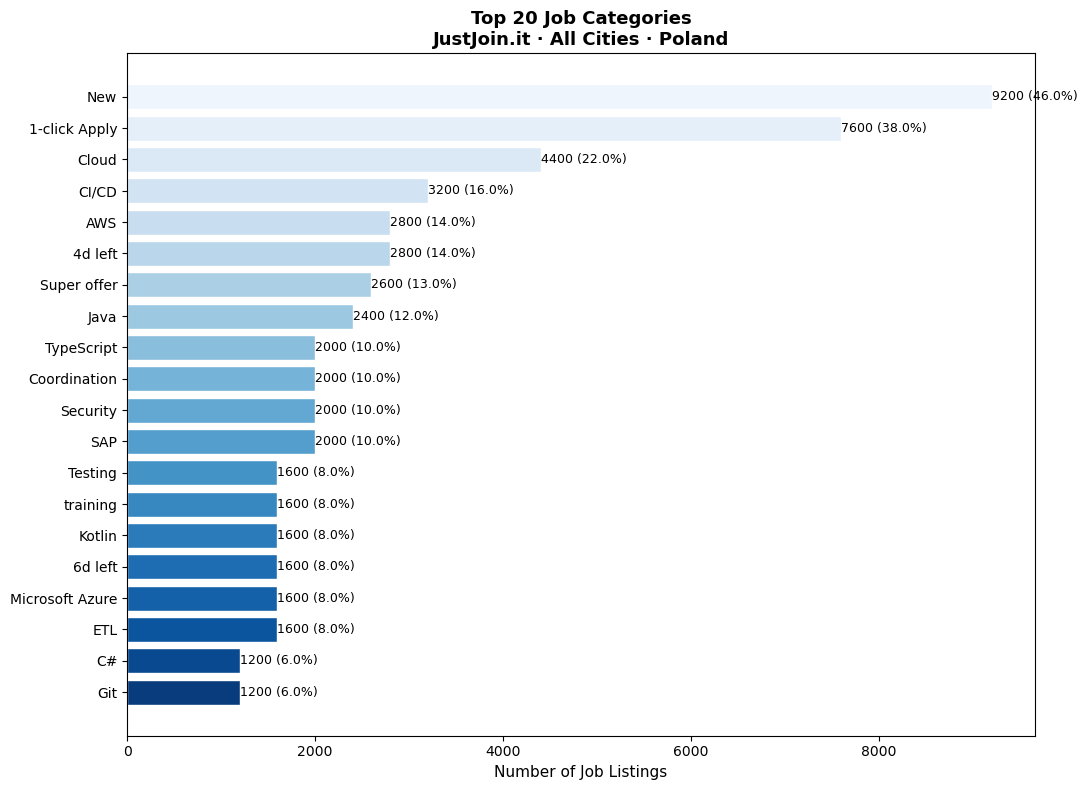

In [57]:
# ── Plot 1: Top 20 Job skills/Categories ───────────────────────────────────────
top_skills = tag_counts.head(20).sort_values('count')
fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(top_skills['skills'], top_skills['count'],
               color=sns.color_palette('Blues_r', len(top_skills)), edgecolor='white')
for bar, (_, row) in zip(bars, top_skills.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{int(row['count'])} ({row['percentage']}%)", va='center', fontsize=9)
ax.set_xlabel('Number of Job Listings', fontsize=11)
ax.set_title('Top 20 Job Categories\nJustJoin.it · All Cities · Poland',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot1_top_skills.png', dpi=150, bbox_inches='tight')
plt.show()


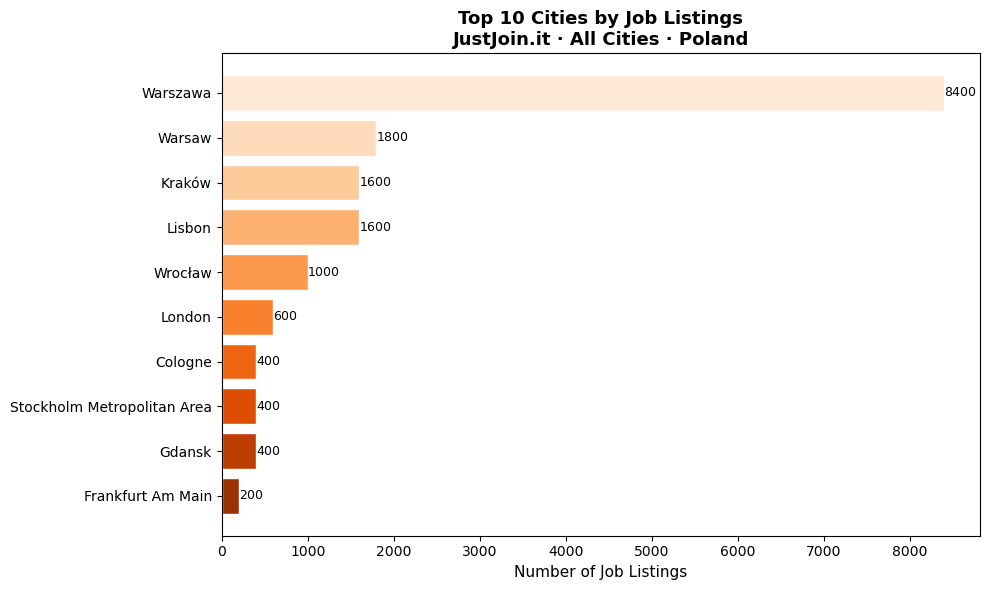

In [59]:
# ── Plot 2: Top 10 Cities ─────────────────────────────────────────────────────
top_cities = df['city'].value_counts().head(10).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_cities.index, top_cities.values,
               color=sns.color_palette('Oranges_r', len(top_cities)), edgecolor='white')
for bar, val in zip(bars, top_cities.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Number of Job Listings', fontsize=11)
ax.set_title('Top 10 Cities by Job Listings\nJustJoin.it · All Cities · Poland',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_top_cities.png', dpi=150, bbox_inches='tight')
plt.show()


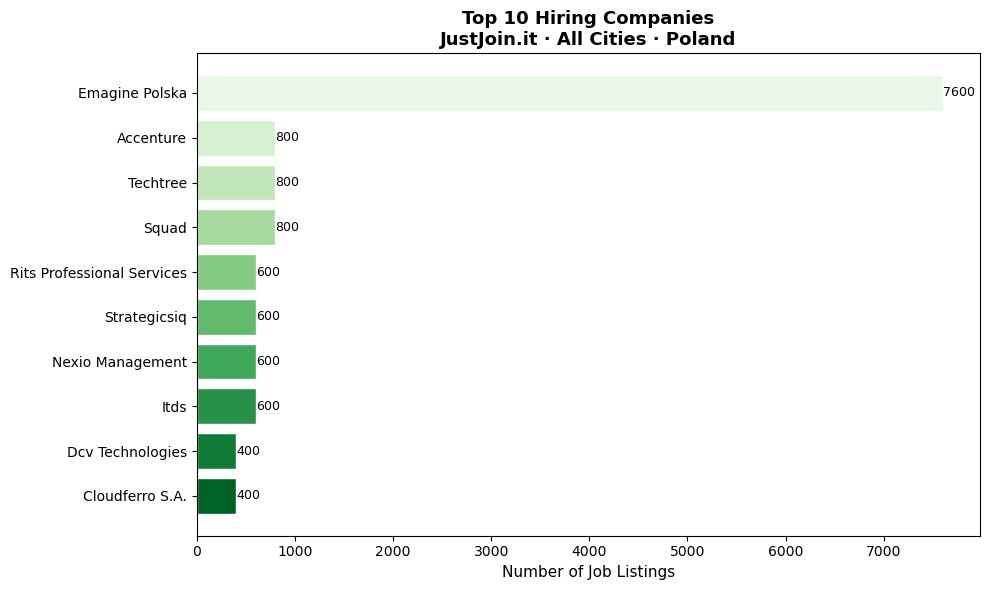

In [61]:
# ── Plot 3: Top 10 Companies ──────────────────────────────────────────────────
top_companies = df['company'].value_counts().head(10).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_companies.index, top_companies.values,
               color=sns.color_palette('Greens_r', len(top_companies)), edgecolor='white')
for bar, val in zip(bars, top_companies.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Number of Job Listings', fontsize=11)
ax.set_title('Top 10 Hiring Companies\nJustJoin.it · All Cities · Poland',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_top_companies.png', dpi=150, bbox_inches='tight')
plt.show()


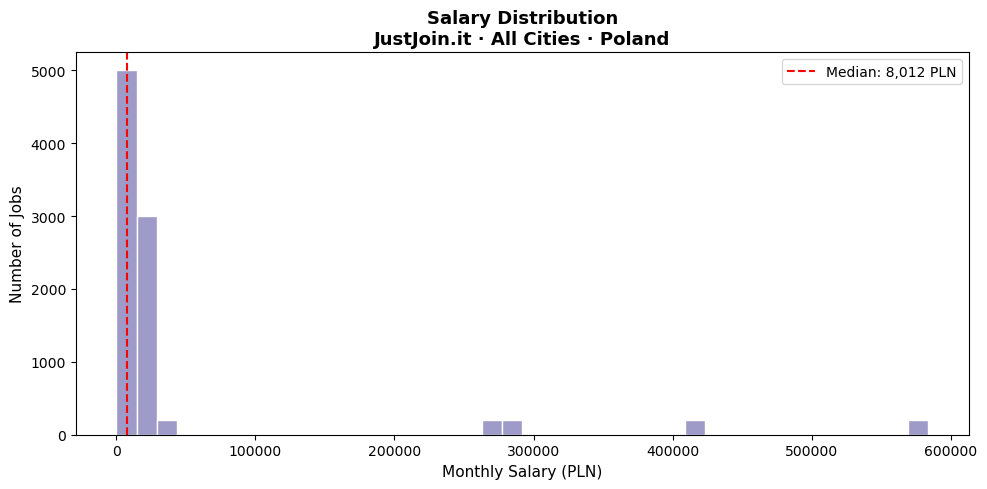

In [63]:
# ── Plot 4: Salary Distribution ───────────────────────────────────────────────
df_sal = df[df['salary_mid'].notna()]
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_sal['salary_mid'], bins=40,
        color=sns.color_palette('Purples_r', 1)[0], edgecolor='white')
ax.axvline(df_sal['salary_mid'].median(), color='red', linestyle='--',
           label=f'Median: {df_sal["salary_mid"].median():,.0f} PLN')
ax.set_xlabel('Monthly Salary (PLN)', fontsize=11)
ax.set_ylabel('Number of Jobs', fontsize=11)
ax.set_title('Salary Distribution\nJustJoin.it · All Cities · Poland',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot4_salary.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Export to CSV

In [65]:
df.to_csv('justjoin_jobs_cleaned.csv', index=False, encoding='utf-8-sig')
print('Saved: justjoin_jobs_cleaned.csv')
tag_counts.to_csv('justjoin_tag_counts.csv', index=False)
print('Saved: justjoin_tag_counts.csv')

print('\n' + '='*50)
print('FINAL SUMMARY')
print('='*50)
print(f'  Total jobs scraped:    {len(df)}')
print(f'  Unique companies:      {df["company"].nunique()}')
print(f'  Unique cities:         {df["city"].nunique()}')
print(f'  Jobs with salary:      {df["salary_from"].notna().sum()}')
print(f'  Remote jobs:           {df["remote"].sum()}')
print(f'  Top city:              {df["city"].value_counts().index[0]}')
print(f'  Top company:           {df["company"].value_counts().index[0]}')
print('='*50)


Saved: justjoin_jobs_cleaned.csv
Saved: justjoin_tag_counts.csv

FINAL SUMMARY
  Total jobs scraped:    20000
  Unique companies:      41
  Unique cities:         28
  Jobs with salary:      9000
  Remote jobs:           6200
  Top city:              Warszawa
  Top company:           Emagine Polska
